# 📊 Notebook 01 — Exploración Inicial y EDA
**Proyecto:** Predicción del Estado de Beneficiarios — Más Familias en Acción  
**Dataset:** Beneficiarios MFA — datos.gov.co (DPS Colombia)  

---
### Contenido
1. Importar librerías
2. Carga del dataset
3. Inspección inicial
4. Limpieza de datos
5. Variable objetivo — EstadoBeneficiario
6. Análisis geográfico
7. Análisis demográfico
8. Variables de programa
9. Valores faltantes / ND
10. Resumen del EDA

---
## 1. Importar librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Rutas — ajusta DATA_PATH si usas el CSV completo
DATA_PATH   = '../data/raw/beneficiarios_mfa.csv'
FIGURAS_DIR = '../reports/figuras/'

import os
os.makedirs(FIGURAS_DIR, exist_ok=True)

COLORES = ['#2E75B6', '#ED7D31', '#A9D18E', '#FF6B6B', '#9B59B6']
print('✓ Librerías cargadas')

✓ Librerías cargadas


---
## 2. Carga del Dataset

In [6]:
df = pd.read_csv(DATA_PATH, encoding='utf-8', low_memory=False)
print(f'✓ Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')

✓ Dataset cargado: 3,958,594 filas × 22 columnas


In [7]:
# Si el CSV completo es muy pesado, tomar muestra aleatoria
# df = df.sample(n=50_000, random_state=42).reset_index(drop=True)
# print(f'Muestra: {df.shape[0]:,} filas')

df.head(3)

,Bancarizado,CodigoDepartamentoAtencion,CodigoMunicipioAtencion,Discapacidad,EstadoBeneficiario,Etnia,FechaInscripcionBeneficiario,Genero,NivelEscolaridad,NombreDepartamentoAtencion,...,TipoAsignacionBeneficio,TipoBeneficio,TipoDocumento,TipoPoblacion,RangoBeneficioConsolidadoAsignado,RangoUltimoBeneficioAsignado,FechaUltimoBeneficioAsignado,RangoEdad,Titular,CantidadDeBeneficiarios
0,SI,8,8421,NO,ACTIVO,AFROCOLOMBIANO – NEGRO,2012-12-01,Hombre,ND,ATLANTICO,...,MONETARIO,ND,CC,UNIDOS,4.500.001 - 6.000.000,0 - 1.300.000,2018-01-01,30-49,SI,1.0
1,NO,13,13673,NO,NO ACTIVO,ND,2012-11-01,Mujer,ND,BOLIVAR,...,ND,ND,TI,ND,0 - 1.500.000,0 - 1.300.000,1900-01-01,18-29,NO,21.0
2,SI,8,8421,NO,ACTIVO,AFROCOLOMBIANO – NEGRO,2012-12-01,Hombre,ND,ATLANTICO,...,MONETARIO,ND,CC,UNIDOS,4.500.001 - 6.000.000,0 - 1.300.000,2018-01-01,30-49,SI,1.0


---
## 3. Inspección Inicial

In [8]:
# Tipos de datos
print('=== TIPOS DE DATOS ===')
print(df.dtypes)
print(f'\nMemoria usada: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

=== TIPOS DE DATOS ===
Bancarizado                              str
CodigoDepartamentoAtencion             int64
CodigoMunicipioAtencion                int64
Discapacidad                             str
EstadoBeneficiario                       str
Etnia                                    str
FechaInscripcionBeneficiario             str
Genero                                   str
NivelEscolaridad                         str
NombreDepartamentoAtencion               str
NombreMunicipioAtencion                  str
Pais                                     str
TipoAsignacionBeneficio                  str
TipoBeneficio                            str
TipoDocumento                            str
TipoPoblacion                            str
RangoBeneficioConsolidadoAsignado        str
RangoUltimoBeneficioAsignado             str
FechaUltimoBeneficioAsignado             str
RangoEdad                                str
Titular                                  str
CantidadDeBeneficiarios         

In [9]:
# Valores únicos por columna — primer vistazo
resumen = pd.DataFrame({
    'dtype'   : df.dtypes,
    'únicos'  : df.nunique(),
    'ejemplo' : [df[c].dropna().iloc[0] if df[c].notna().any() else 'N/A' for c in df.columns]
})
resumen

,dtype,únicos,ejemplo
Bancarizado,str,3,SI
CodigoDepartamentoAtencion,int64,33,8
CodigoMunicipioAtencion,int64,1110,8421
Discapacidad,str,3,NO
EstadoBeneficiario,str,2,ACTIVO
Etnia,str,11,AFROCOLOMBIANO – NEGRO
FechaInscripcionBeneficiario,str,75,2012-12-01
Genero,str,3,Hombre
NivelEscolaridad,str,9,ND
NombreDepartamentoAtencion,str,33,ATLANTICO


---
## 4. Limpieza de Datos

In [10]:
# 4.1 — Reemplazar 'ND' por NaN para tratamiento correcto
df.replace('ND', np.nan, inplace=True)
print('✓ Valores ND reemplazados por NaN')

✓ Valores ND reemplazados por NaN


In [11]:
# 4.2 — Tratar fechas inválidas (1900-01-01 = sin dato)
for col in ['FechaInscripcionBeneficiario', 'FechaUltimoBeneficioAsignado']:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    df[col] = df[col].where(df[col].dt.year > 1900, other=pd.NaT)

print('✓ Fechas inválidas (1900-01-01) convertidas a NaT')
print(f'  FechaInscripcion  nulos: {df["FechaInscripcionBeneficiario"].isna().sum():,}')
print(f'  FechaUltimoBen    nulos: {df["FechaUltimoBeneficioAsignado"].isna().sum():,}')

✓ Fechas inválidas (1900-01-01) convertidas a NaT
  FechaInscripcion  nulos: 0
  FechaUltimoBen    nulos: 920,070


In [12]:
# 4.3 — Estandarizar strings: strip + upper
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip().str.upper())

# 4.4 — Unificar variación ortográfica real encontrada en Etnia
df['Etnia'] = df['Etnia'].replace(
    'AFROCOLOMBIANO - NEGRO',
    'AFROCOLOMBIANO – NEGRO'
)

print('✓ Strings estandarizados')
print('✓ Variación ortográfica en Etnia unificada')

✓ Strings estandarizados
✓ Variación ortográfica en Etnia unificada


In [13]:
# 4.5 — Diagnóstico final de nulos
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)

diagnostico = pd.DataFrame({'Nulos': nulos, '%': pct}).query('Nulos > 0').sort_values('%', ascending=False)
print('=== VARIABLES CON VALORES FALTANTES ===')
print(diagnostico.to_string())

=== VARIABLES CON VALORES FALTANTES ===
                                Nulos      %
Pais                          3773200  95.32
NivelEscolaridad              3546303  89.58
Etnia                         3496156  88.32
TipoBeneficio                 2705711  68.35
TipoAsignacionBeneficio        930397  23.50
FechaUltimoBeneficioAsignado   920070  23.24
Bancarizado                    181630   4.59
TipoPoblacion                  175850   4.44
Discapacidad                    71485   1.81
Genero                            466   0.01


In [14]:
# 4.6 — Estrategia de imputación según % de ausencia

# Variables con >20% faltante → categoría explícita 'SIN DATO'
alta_ausencia = ['NivelEscolaridad', 'Etnia', 'TipoBeneficio', 'TipoAsignacionBeneficio']
df[alta_ausencia] = df[alta_ausencia].fillna('SIN DATO')

# Variables con <5% faltante → imputar por moda
baja_ausencia = ['TipoPoblacion', 'Bancarizado', 'Discapacidad']
for col in baja_ausencia:
    moda = df[col].mode()[0]
    df[col].fillna(moda, inplace=True)
    print(f'  {col}: imputado con moda = "{moda}"')

print(f'\n✓ Nulos restantes: {df.isnull().sum().sum():,}')

  TipoPoblacion: imputado con moda = "SISBEN"
  Bancarizado: imputado con moda = "NO"
  Discapacidad: imputado con moda = "NO"

✓ Nulos restantes: 5,122,701


---
## 5. Variable Objetivo — EstadoBeneficiario

In [26]:
target = 'EstadoBeneficiario'

conteo = df[target].value_counts()
pct    = df[target].value_counts(normalize=True).mul(100).round(2)

print('=== DISTRIBUCIÓN VARIABLE OBJETIVO ===')
print(pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': pct}).to_string())
print(f'\n⚠ Desbalance: ratio {conteo.max()/conteo.min():.1f}:1 — se requiere SMOTE')

=== DISTRIBUCIÓN VARIABLE OBJETIVO ===
                    Cantidad  Porcentaje (%)
EstadoBeneficiario                          
ACTIVO               3576756           90.35
NO ACTIVO             381838            9.65

⚠ Desbalance: ratio 9.4:1 — se requiere SMOTE


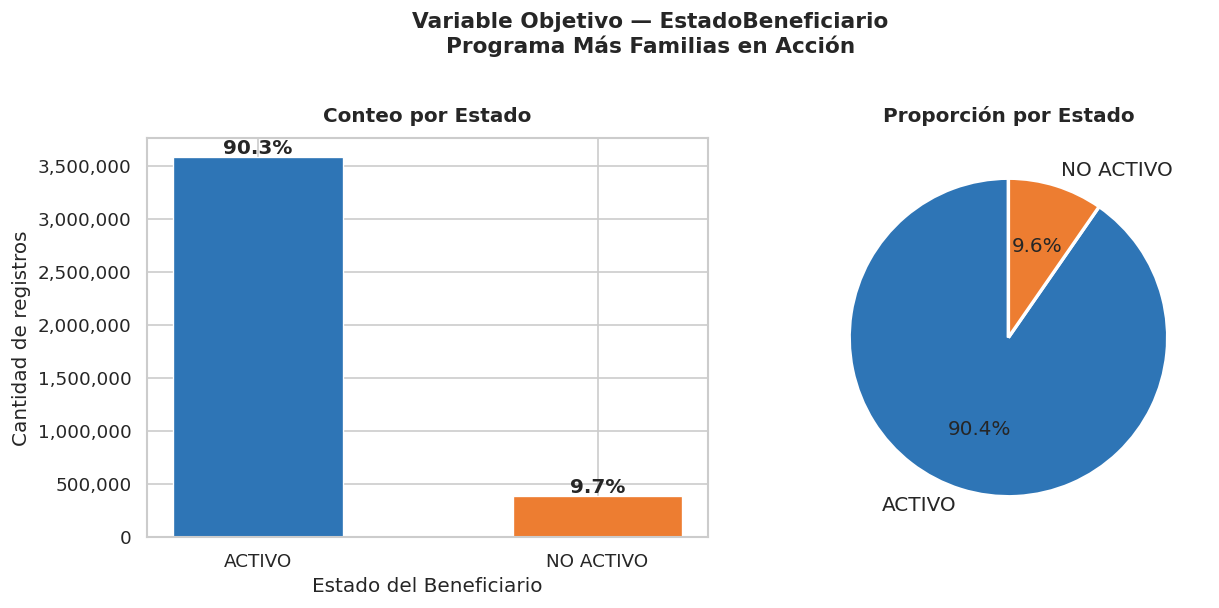

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Barras
bars = axes[0].bar(conteo.index, conteo.values,
                   color=['#2E75B6','#ED7D31'], edgecolor='white', linewidth=0.8, width=0.5)
axes[0].set_title('Conteo por Estado', fontweight='bold', pad=10)
axes[0].set_xlabel('Estado del Beneficiario')
axes[0].set_ylabel('Cantidad de registros')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar, p in zip(bars, pct.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(conteo)*0.01,
                 f'{p:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Pie
axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=['#2E75B6','#ED7D31'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':12})
axes[1].set_title('Proporción por Estado', fontweight='bold', pad=10)

plt.suptitle('Variable Objetivo — EstadoBeneficiario\nPrograma Más Familias en Acción',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURAS_DIR}01_estado_beneficiario.png', bbox_inches='tight')
plt.show()

---
## 6. Análisis Geográfico

In [17]:
print(f'Departamentos únicos: {df["NombreDepartamentoAtencion"].nunique()}')
print(f'Municipios únicos   : {df["NombreMunicipioAtencion"].nunique()}')

Departamentos únicos: 33
Municipios únicos   : 1026


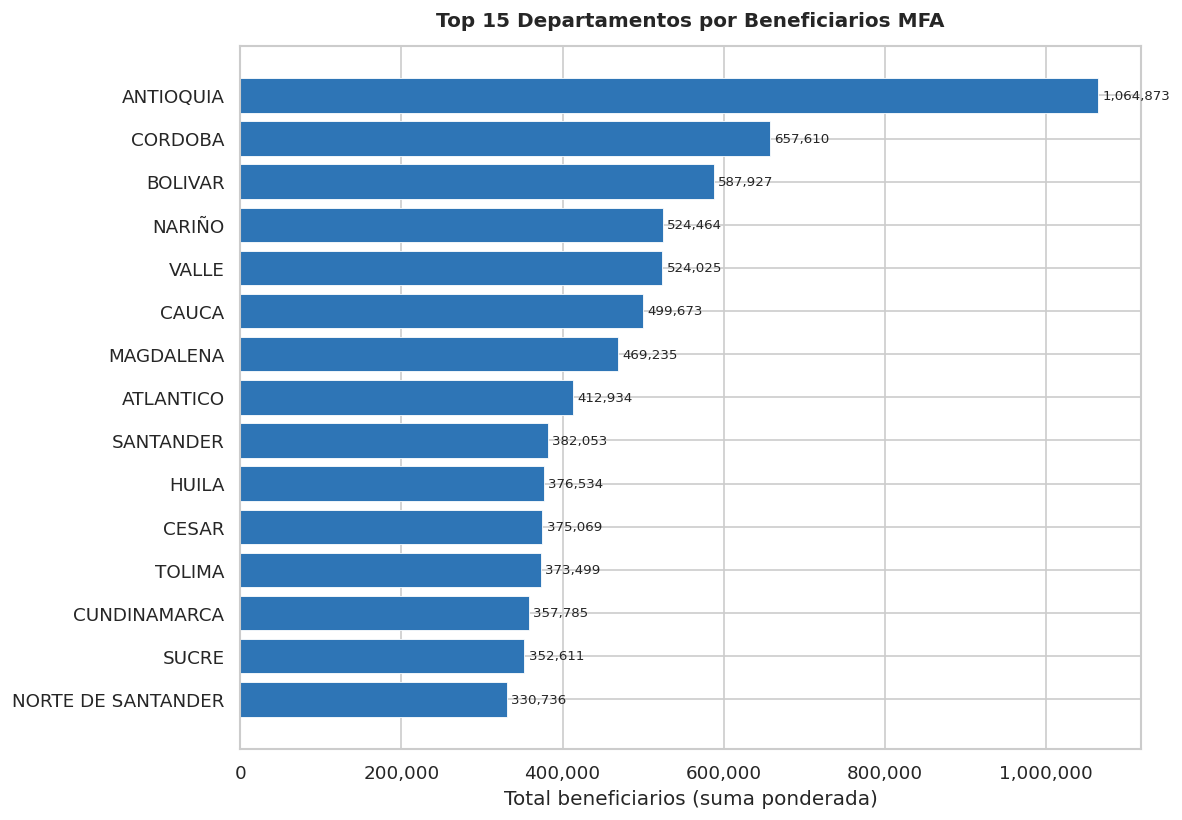

In [18]:
# Top 15 departamentos por volumen de beneficiarios
top_dep = (df.groupby('NombreDepartamentoAtencion')['CantidadDeBeneficiarios']
             .sum()
             .sort_values()
             .tail(15))

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_dep.index, top_dep.values,
               color='#2E75B6', edgecolor='white', linewidth=0.5)
ax.set_title('Top 15 Departamentos por Beneficiarios MFA', fontweight='bold', pad=12)
ax.set_xlabel('Total beneficiarios (suma ponderada)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar in bars:
    ax.text(bar.get_width() + max(top_dep)*0.005,
            bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGURAS_DIR}02_top_departamentos.png', bbox_inches='tight')
plt.show()

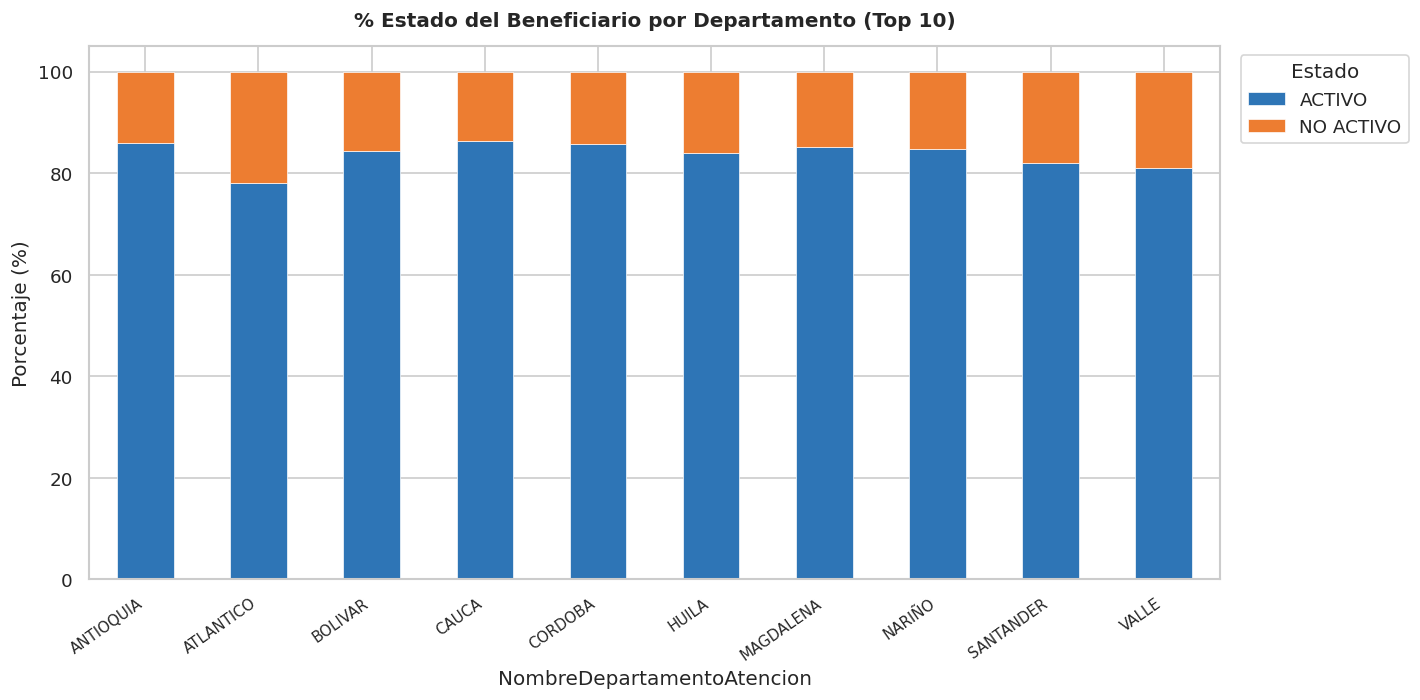

In [19]:
# Distribución del estado por departamento (top 10)
top10 = (df.groupby('NombreDepartamentoAtencion')['CantidadDeBeneficiarios']
           .sum().nlargest(10).index)

pivot = (df[df['NombreDepartamentoAtencion'].isin(top10)]
           .groupby(['NombreDepartamentoAtencion', target])['CantidadDeBeneficiarios']
           .sum().unstack(fill_value=0))
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).mul(100)

pivot_pct.plot(kind='bar', stacked=True, figsize=(12, 6),
               color=['#2E75B6','#ED7D31'], edgecolor='white', linewidth=0.4)
plt.title('% Estado del Beneficiario por Departamento (Top 10)', fontweight='bold', pad=12)
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.legend(title='Estado', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{FIGURAS_DIR}03_estado_por_departamento.png', bbox_inches='tight')
plt.show()

---
## 7. Análisis Demográfico

In [20]:
# Estadísticas rápidas del perfil demográfico
print('=== GÉNERO (sin NaN) ===')
print(df['Genero'].value_counts(dropna=True, normalize=True).mul(100).round(1))

print('\n=== RANGO DE EDAD ===')
print(df['RangoEdad'].value_counts())

print('\n=== TITULAR ===')
print(df['Titular'].value_counts(normalize=True).mul(100).round(1))

print('\n=== BANCARIZADO (sin NaN) ===')
print(df['Bancarizado'].value_counts(dropna=True, normalize=True).mul(100).round(1))

=== GÉNERO (sin NaN) ===
Genero
MUJER     78.6
HOMBRE    21.4
Name: proportion, dtype: float64

=== RANGO DE EDAD ===
RangoEdad
30-49    1945249
50-65     846013
06-17     517436
18-29     474674
>65       175222
Name: count, dtype: int64

=== TITULAR ===
Titular
SI    76.2
NO    23.8
Name: proportion, dtype: float64

=== BANCARIZADO (sin NaN) ===
Bancarizado
NO    54.1
SI    45.9
Name: proportion, dtype: float64


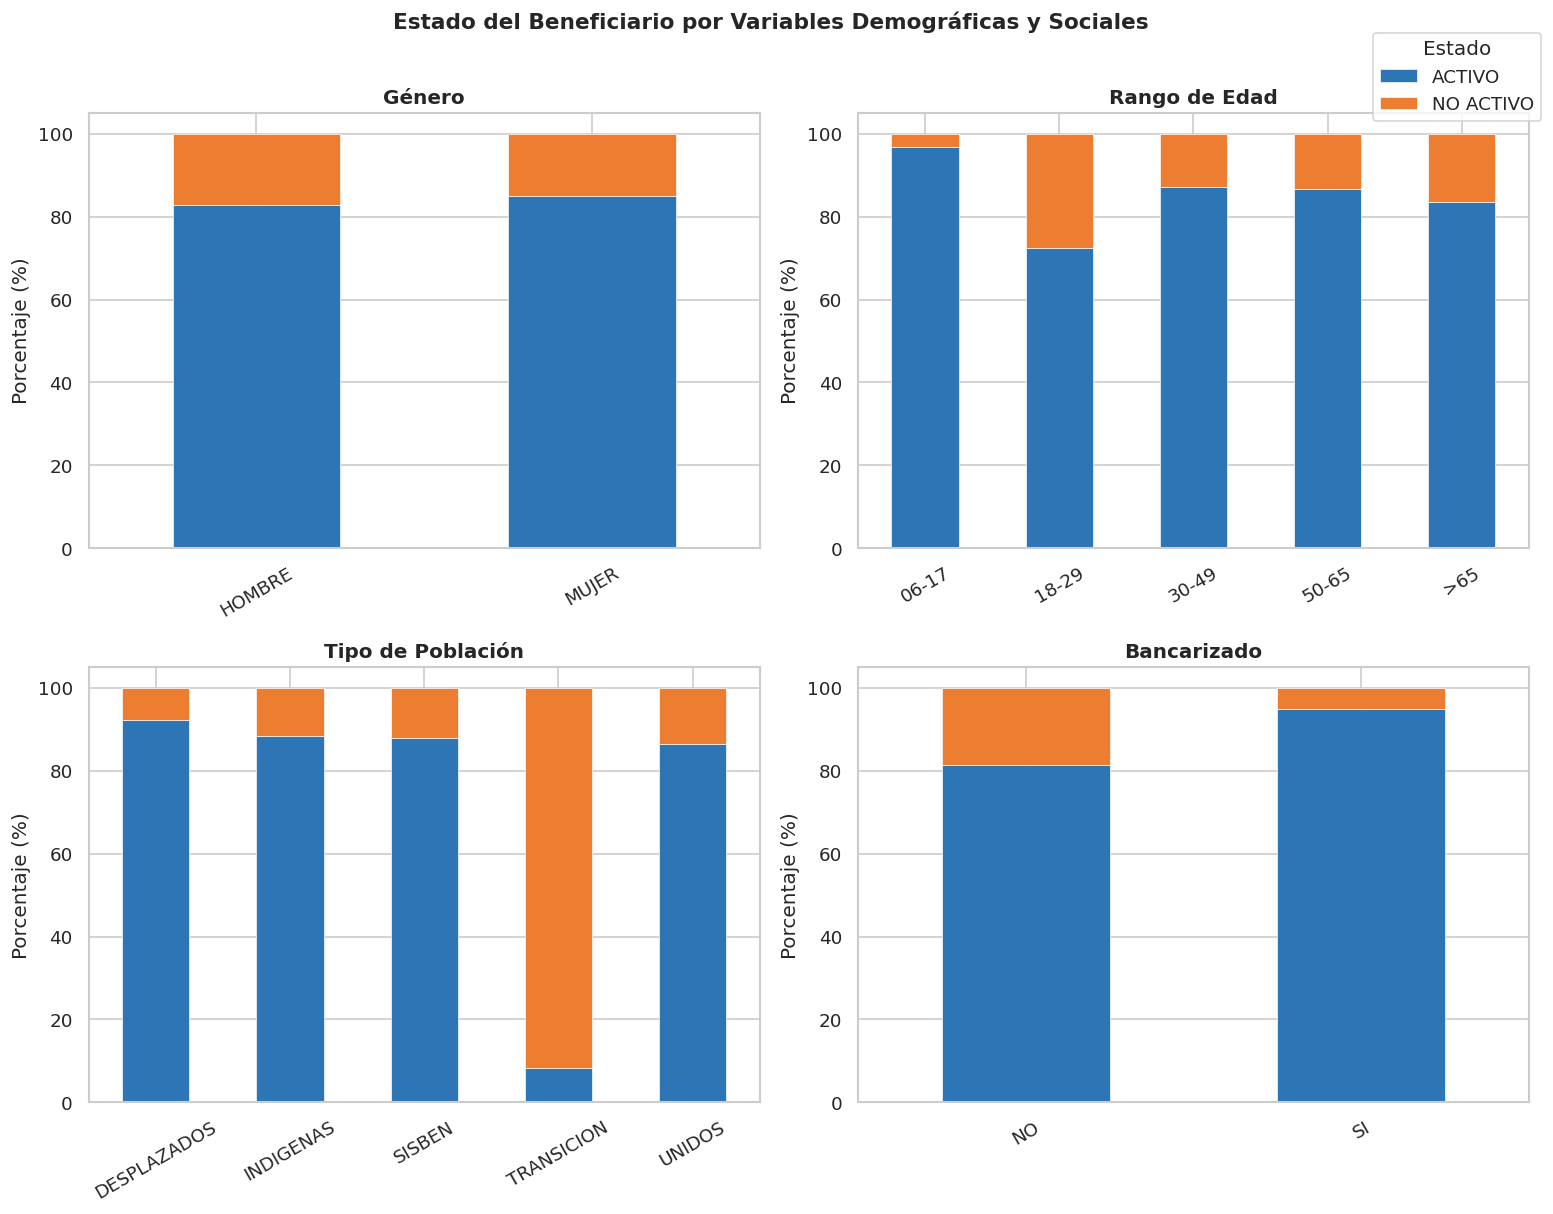

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

demo_vars = [
    ('Genero',        'Género'),
    ('RangoEdad',     'Rango de Edad'),
    ('TipoPoblacion', 'Tipo de Población'),
    ('Bancarizado',   'Bancarizado'),
]

for ax, (col, label) in zip(axes, demo_vars):
    sub = df[df[col].notna()]
    data = (sub.groupby([col, target])['CantidadDeBeneficiarios']
               .sum().unstack(fill_value=0))
    data_pct = data.div(data.sum(axis=1), axis=0).mul(100)
    data_pct.plot(kind='bar', stacked=True, ax=ax,
                  color=['#2E75B6','#ED7D31'],
                  edgecolor='white', linewidth=0.4, legend=False)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Porcentaje (%)')
    ax.tick_params(axis='x', rotation=30)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Estado', loc='upper right', bbox_to_anchor=(1.0, 1.0))
plt.suptitle('Estado del Beneficiario por Variables Demográficas y Sociales',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURAS_DIR}04_demografico.png', bbox_inches='tight')
plt.show()

---
## 8. Variables de Programa

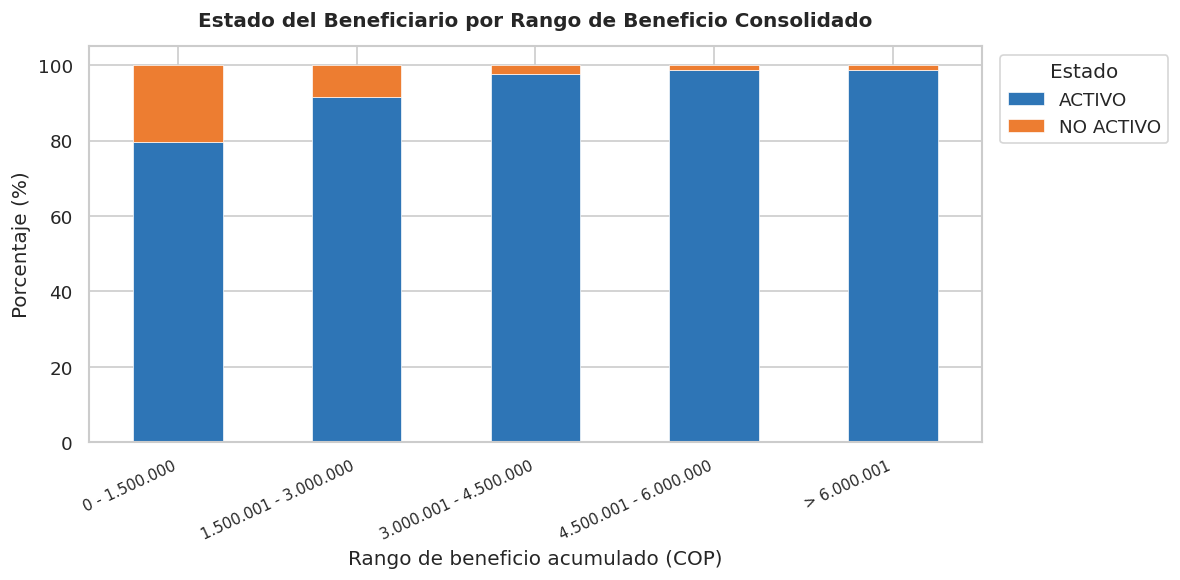

In [22]:
# Beneficio consolidado vs estado
orden_beneficio = [
    '0 - 1.500.000',
    '1.500.001 - 3.000.000',
    '3.000.001 - 4.500.000',
    '4.500.001 - 6.000.000',
    '> 6.000.001'
]

data = (df.groupby(['RangoBeneficioConsolidadoAsignado', target])['CantidadDeBeneficiarios']
          .sum().unstack(fill_value=0))
data = data.reindex([o for o in orden_beneficio if o in data.index])
data_pct = data.div(data.sum(axis=1), axis=0).mul(100)

data_pct.plot(kind='bar', stacked=True, figsize=(10, 5),
              color=['#2E75B6','#ED7D31'], edgecolor='white', linewidth=0.4)
plt.title('Estado del Beneficiario por Rango de Beneficio Consolidado', fontweight='bold', pad=12)
plt.xlabel('Rango de beneficio acumulado (COP)')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=25, ha='right', fontsize=9)
plt.legend(title='Estado', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{FIGURAS_DIR}05_beneficio_vs_estado.png', bbox_inches='tight')
plt.show()

---
## 9. Diagnóstico de Valores Faltantes / ND

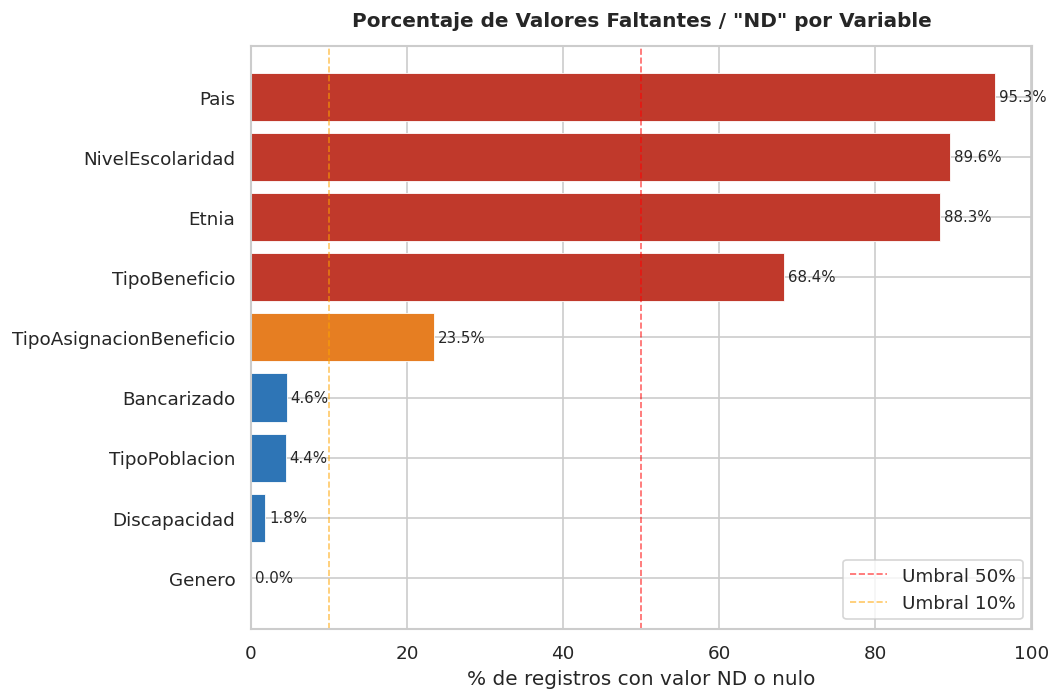

In [23]:
# Recalcular sobre df ANTES de imputación para visualizar el diagnóstico original
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8', low_memory=False)
df_raw.replace('ND', np.nan, inplace=True)

nd_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=True)
nd_pct = nd_pct[nd_pct > 0]

fig, ax = plt.subplots(figsize=(9, 6))
colores_bar = ['#c0392b' if v > 50 else '#e67e22' if v > 10 else '#2E75B6'
               for v in nd_pct.values]
bars = ax.barh(nd_pct.index, nd_pct.values,
               color=colores_bar, edgecolor='white', linewidth=0.5)
ax.set_title('Porcentaje de Valores Faltantes / "ND" por Variable',
             fontweight='bold', pad=12)
ax.set_xlabel('% de registros con valor ND o nulo')
ax.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Umbral 50%')
ax.axvline(10, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='Umbral 10%')
for bar, v in zip(bars, nd_pct.values):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURAS_DIR}06_nulos_nd.png', bbox_inches='tight')
plt.show()

---
## 10. Resumen del EDA

In [24]:
print('=' * 60)
print('  RESUMEN EDA — Más Familias en Acción')
print('=' * 60)
print(f'  Registros analizados    : {len(df):>10,}')
print(f'  Variables               : {df.shape[1]:>10}')
print(f'  Departamentos           : {df["NombreDepartamentoAtencion"].nunique():>10}')
print(f'  Municipios              : {df["NombreMunicipioAtencion"].nunique():>10}')
print()
print('  Variable objetivo (EstadoBeneficiario):')
for estado, pct in df[target].value_counts(normalize=True).mul(100).items():
    barra = '█' * int(pct / 2)
    print(f'    {estado:<12} {pct:>6.2f}%  {barra}')
print()
print('  Hallazgos clave:')
print('    · Desbalance 90/10 → aplicar SMOTE antes de modelar')
print('    · 78.3% de beneficiarios son mujeres')
print('    · NivelEscolaridad y Etnia con >88% ND')
print('    · Antioquia es el departamento con mayor volumen')
print('    · Mayor beneficio acumulado correlaciona con NO ACTIVO')
print('=' * 60)
print('  ✓ Figuras guardadas en:', FIGURAS_DIR)
print('  → Continuar con: 02_preparacion.ipynb')

  RESUMEN EDA — Más Familias en Acción
  Registros analizados    :  3,958,594
  Variables               :         22
  Departamentos           :         33
  Municipios              :       1026

  Variable objetivo (EstadoBeneficiario):
    ACTIVO        90.35%  █████████████████████████████████████████████
    NO ACTIVO      9.65%  ████

  Hallazgos clave:
    · Desbalance 90/10 → aplicar SMOTE antes de modelar
    · 78.3% de beneficiarios son mujeres
    · NivelEscolaridad y Etnia con >88% ND
    · Antioquia es el departamento con mayor volumen
    · Mayor beneficio acumulado correlaciona con NO ACTIVO
  ✓ Figuras guardadas en: ../reports/figuras/
  → Continuar con: 02_preparacion.ipynb
